# Rocket Immunoelectrophoresis

## Objective & Background
To determine the antigen concentrations of our experimental samples, we use standard samples with known antigen concentrations in an electrophoresis setup using an antibody-impregnated agarose gel matrix.

---

> **Analytical Strategy:** As the antigen is driven forward along the voltage gradient, it creates a vertical "rocket", the length of which is directly proportional to the logarithm of the antigen concentration. This notebook will model a **Semi-Logarithmic Regression Plot** of the logarithm of the antigen concentration against the rocket height in order to linearize a calibration line of which we can use to calculate the antigen concentrations of our unknown samples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
#Standard reference antigen concentrations (Percent, %)
conc = np.array([4, 2, 1, 0.5])

#Observed rocket height of standard reference samples (Millimeter, mm)
height = np.array([35, 22, 16, 5])

#Observed rocket height of experimental samples (Millimeter, mm)
t_height = np.array([24, 17])

In [3]:
#We transform antigen concentrations into log space to linearize the calibration line
log_conc = np.log10(conc)

#We perform Ordinary Least Squares linear regression where x = log10(antigen concentration) and y = rocket height
slope, intercept, r_value, p_value, std_err = stats.linregress(log_conc, height)

In [4]:
#Solve the unknown concentrations using the formula antigen concentration = 10 ^ (slope * rocket height + y-intercept)
log_t_conc = (t_height - intercept) / slope
t_conc = 10**log_t_conc

print(f"Sample T1 | Height: {t_height[0]}mm  ->  Approx. Concentration: {t_conc[0]:.2f}%")
print(f"Sample T2 | Height: {t_height[1]}mm  ->  Approx. Concentration: {t_conc[1]:.2f}%")

Sample T1 | Height: 24mm  ->  Approx. Concentration: 1.96%
Sample T2 | Height: 17mm  ->  Approx. Concentration: 1.18%


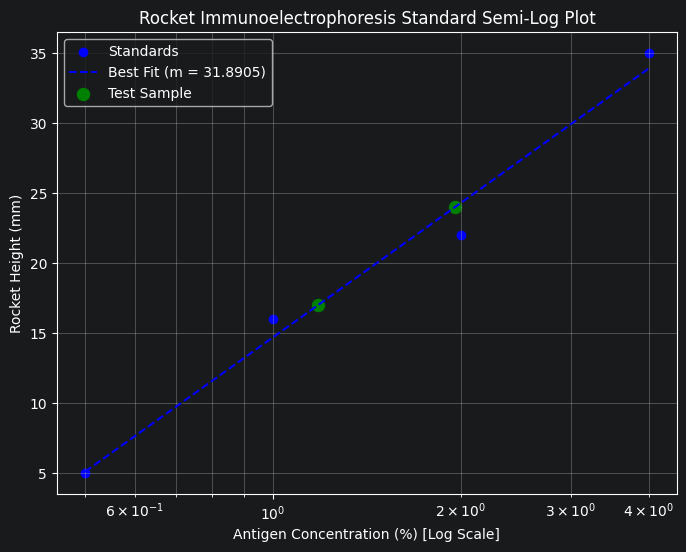

In [5]:
#Semi-Log Plot
plt.figure(figsize = (8, 6))

#Plot scatter points of raw empirical data points from observation
plt.scatter(conc, height, color = 'blue', label = 'Standards')

#Generate 100 evenly spaced steps across concentration windows to plot a straight calibration line
x_fit = np.linspace(min(conc), max(conc), 100)
y_fit = slope * np.log10(x_fit) + intercept
plt.plot(x_fit, y_fit, color = 'blue', linestyle = '--', label = f'Best Fit (m = {slope:.4f})')

#Plot scatter points where observed data points from experimental sample meet the calibration line
plt.scatter(t_conc, t_height, color = 'green', s = 75, label = 'Test Sample')

#Canvas formatting
plt.xscale('log')
plt.xlabel('Antigen Concentration (%) [Log Scale]')
plt.ylabel('Rocket Height (mm)')
plt.title('Rocket Immunoelectrophoresis Standard Semi-Log Plot')
plt.grid(True, which = "both", ls = "-", alpha = 0.5)
plt.legend()
plt.show()